# CSC4792 Team 9 — Luanshya Municipal Council Open Data

Data collection, cleaning, and exploration notebook for the Data in Brief
submission.

Sources: Luanshya Municipal Council website (https://www.luanshyacouncil.gov.zm/) —
CDF allocations/projects, budgets & financial statements, the District Integrated
Development Plan (IDP), and council news/notices touching on resolutions and
ward-level programs.

**Status:** raw data collected (128 files) and cleaned into four tidy CSVs in
`data/processed/`. See `README.md` and the `scripts/clean.py` docstring for
what's covered and the known limitations (about half the PDFs are scanned
images with no usable text layer; CDF project-list PDFs aren't extracted yet).

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path('data/raw')
PROCESSED = Path('data/processed')

## 2. Data collection

Run once, from a machine with normal internet access:
```
python scripts/scrape.py
```
See `data/raw/sources_seed.csv` for the hand-curated list of known source
pages/documents this starts from, and `data/raw/manifest.csv` (produced by
the scraper) for what was actually retrieved.

In [2]:
manifest_path = RAW / 'manifest.csv'
if manifest_path.exists():
    manifest = pd.read_csv(manifest_path)
    display(manifest)
else:
    print('manifest.csv not found yet — run scripts/scrape.py first.')

,url,local_path,http_status,content_type,bytes
0,https://www.luanshyacouncil.gov.zm/?page_id=3525,data\raw\pages\page_3525.html,200,cached,124105
1,https://www.luanshyacouncil.gov.zm/?page_id=959,data\raw\pages\page_959.html,200,cached,127493
2,https://www.luanshyacouncil.gov.zm/?page_id=275,data\raw\pages\page_275.html,200,cached,96804
3,https://www.luanshyacouncil.gov.zm/?page_id=118,data\raw\pages\page_118.html,200,cached,99914
4,https://www.luanshyacouncil.gov.zm/?page_id=1548,data\raw\pages\page_1548.html,200,cached,104068
...,...,...,...,...,...
153,https://www.luanshyacouncil.gov.zm/wp-content/...,data\raw\pdfs\The-Urban-and-Regional-Planning-...,200,cached,123463
154,https://www.luanshyacouncil.gov.zm/?p=4430,data\raw\news\p4430.html,200,cached,99292
155,https://www.luanshyacouncil.gov.zm/?p=4433,data\raw\news\p4433.html,200,cached,97737
156,https://www.luanshyacouncil.gov.zm/?p=4436,data\raw\news\p4436.html,200,cached,101412


## 3. Cleaning / transformation

```
python scripts/clean.py
```
Produces the tidy CSV(s) in `data/processed/` named per the course's
`db-unza26-csc4792-team9-*.csv` convention.

In [3]:
processed_files = sorted(PROCESSED.glob('*.csv'))
processed_files

[PosixPath('data/processed/db-unza26-csc4792-team9-budget-lines.csv'),
 PosixPath('data/processed/db-unza26-csc4792-team9-cdf-beneficiaries.csv'),
 PosixPath('data/processed/db-unza26-csc4792-team9-coverage-validation.csv'),
 PosixPath('data/processed/db-unza26-csc4792-team9-document-index.csv'),
 PosixPath('data/processed/db-unza26-csc4792-team9-news-posts.csv')]

### Document index breakdown

`db-unza26-csc4792-team9-document-index.csv` is the starting point — one row per
raw file, with category, page count, and whether it has a usable text layer.


151 documents indexed


,count
category,
misc,32
cdf_beneficiary_list,26
budget_financial,25
news,16
cdf_project_list,15
notice_minutes,12
legal_regulatory,9
application_form,8
nav_page,7


,with_text_layer,total,no_text_layer
category,,,
application_form,1,8,7
budget_financial,18,25,7
cdf_beneficiary_list,10,26,16
cdf_project_list,7,15,8
idp,True,1,0
legal_regulatory,9,9,0
misc,18,32,14
nav_page,0,0,0
news,0,0,0


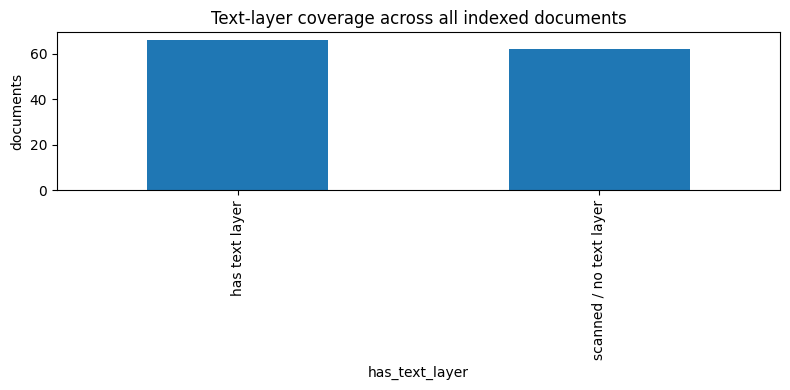

In [4]:
doc_index = pd.read_csv(PROCESSED / 'db-unza26-csc4792-team9-document-index.csv', sep='|')
print(f"{len(doc_index)} documents indexed")
display(doc_index['category'].value_counts().rename('count').to_frame())

text_layer_by_cat = (doc_index.groupby('category')['has_text_layer']
                      .agg(['sum', 'count'])
                      .rename(columns={'sum': 'with_text_layer', 'count': 'total'}))
text_layer_by_cat['no_text_layer'] = text_layer_by_cat['total'] - text_layer_by_cat['with_text_layer']
display(text_layer_by_cat)

fig, ax = plt.subplots(figsize=(8, 4))
doc_index['has_text_layer'].value_counts().rename({True: 'has text layer', False: 'scanned / no text layer'}).plot.bar(ax=ax)
ax.set_ylabel('documents')
ax.set_title('Text-layer coverage across all indexed documents')
plt.tight_layout()
plt.show()


## 4. Exploratory analysis

Quick first look at each processed CSV. `db-unza26-csc4792-team9-cdf-beneficiaries.csv`
intentionally excludes NRC numbers, phone numbers, and dates of birth that
appear in the source PDFs — see `README.md` for why.

260 beneficiary rows from 4 documents


,source_document,list_type,constituency,ward,beneficiary_name,gender,amount_kwacha,year
0,2025-SKILLS-LUANSHYA-CONSTITUENCY.pdf,skills_development,Luanshya,BALUBA,KAPEMBWA CHIFUNDA,M,31325.0,2025
1,2025-SKILLS-LUANSHYA-CONSTITUENCY.pdf,skills_development,Luanshya,BALUBA,MUSUKWA JOSEPHINE,F,28345.0,2025
2,2025-SKILLS-LUANSHYA-CONSTITUENCY.pdf,skills_development,Luanshya,BALUBA,MALENI WARREN,M,28342.0,2025
3,2025-SKILLS-LUANSHYA-CONSTITUENCY.pdf,skills_development,Luanshya,BUTEKO,CHISANGA KENNEDY,M,27045.0,2025
4,2025-SKILLS-LUANSHYA-CONSTITUENCY.pdf,skills_development,Luanshya,BUTEKO,KABWE CHIPILI,M,10300.0,2025


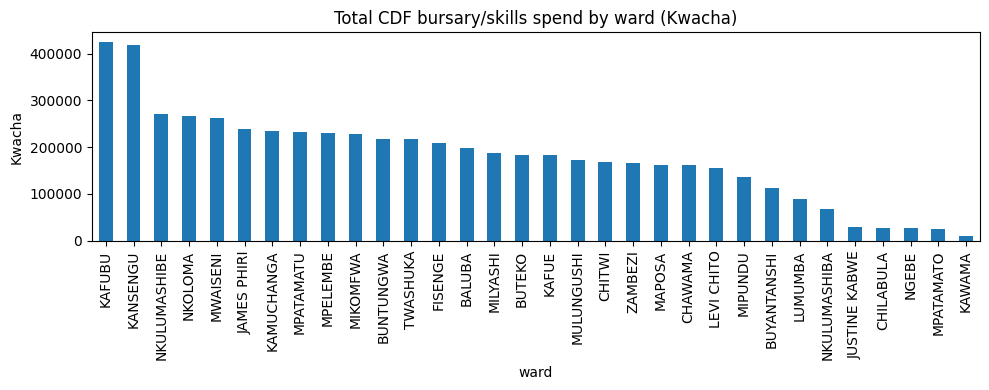

In [5]:
beneficiaries = pd.read_csv(PROCESSED / 'db-unza26-csc4792-team9-cdf-beneficiaries.csv', sep='|')
print(f"{len(beneficiaries)} beneficiary rows from {beneficiaries['source_document'].nunique()} documents")
display(beneficiaries.head())

by_ward = (beneficiaries.groupby('ward')['amount_kwacha']
           .agg(['count', 'sum']).sort_values('sum', ascending=False))
by_ward.plot(kind='bar', y='sum', legend=False, title='Total CDF bursary/skills spend by ward (Kwacha)', figsize=(10, 4))
plt.ylabel('Kwacha')
plt.tight_layout()
plt.show()

In [6]:
budget_lines = pd.read_csv(PROCESSED / 'db-unza26-csc4792-team9-budget-lines.csv', sep='|')
print(f"{len(budget_lines)} budget line rows from {budget_lines['source_document'].nunique()} documents")
display(budget_lines.head())

top_lines = (budget_lines.groupby(['source_document', 'description'])['amount_kwacha']
             .max().sort_values(ascending=False).head(15))
top_lines

3097 budget line rows from 4 documents


,source_document,year,code,description,amount_type,amount_kwacha
0,LUANSHYA-BUDGET-2025.pdf,2025,001,Residential,APPROVED BUDGET 2025,10177176.0
1,LUANSHYA-BUDGET-2025.pdf,2025,001,Residential,REVISED BUDGET 2026,5499066.0
2,LUANSHYA-BUDGET-2025.pdf,2025,001,Residential,BUDGET ESTIMATE 2027,5499066.0
3,LUANSHYA-BUDGET-2025.pdf,2025,002,Commercial,APPROVED BUDGET 2025,1600050.0
4,LUANSHYA-BUDGET-2025.pdf,2025,002,Commercial,REVISED BUDGET 2026,1600050.0


source_document                  description                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
LUANSHYA-BUDGET-2025.pdf         Constituency Development Local Governance Integrated Development Planning Economic and business development Public health and Environmental protection Housing and Community Amenities Recreation Culture and Religion Education and skills development Public order and safety Management and support Services Resource Mobilisation and Management District Health servcies Transport Services Agricultural Services Fisheries and Livestock Social Protection and Commun

In [7]:
news = pd.read_csv(PROCESSED / 'db-unza26-csc4792-team9-news-posts.csv', sep='|')
print(f"{len(news)} news posts")
display(news.drop(columns=['body_text']).sort_values('published_date'))

16 news posts


,source_document,url,title,published_date,wards_mentioned,kwacha_amounts_mentioned,word_count
14,p3975.html,https://www.luanshyacouncil.gov.zm/?p=3975,LUANSHYA MAYOR VISITS MIPUNDU AREA AFTER HEAVY...,2025-12-31,MIPUNDU,NaN,171
13,p3993.html,https://www.luanshyacouncil.gov.zm/?p=3993,"AUTHORITIES, COUNCIL MANAGEMENT, STAKEHOLDERS ...",2026-01-06,MIKOMFWA,NaN,548
12,p4088.html,https://www.luanshyacouncil.gov.zm/?p=4088,LUANSHYA CDF RESOLVES TO FUND K10 MILLION PCEI...,2026-02-20,KAMUCHANGA; MAPOSA; MWAISENI,K10; K10 MILLION,515
11,p4123.html,https://www.luanshyacouncil.gov.zm/?p=4123,INTERNATIONAL WOMENS DAY COUNT DOWN: LUANSHYA ...,2026-03-08,NaN,NaN,112
10,p4156.html,https://www.luanshyacouncil.gov.zm/?p=4156,"NEW BUS TERMINUS COMING, AS LUANSHYA STAKEHOLD...",2026-03-23,NaN,NaN,578
8,p4208.html,https://www.luanshyacouncil.gov.zm/?p=4208,FULL COUNCIL MEETING IN PICTURES.,2026-04-13,NaN,NaN,220
9,p4199.html,https://www.luanshyacouncil.gov.zm/?p=4199,GOVERNMENT’S SCHOOLS FEEDING PROGRAM RECIEVES ...,2026-04-13,FISENGE; MIKOMFWA,K 1.3 million; K40 million,837
7,p4221.html,https://www.luanshyacouncil.gov.zm/?p=4221,"K24 MILLION WORTH LUANSHYA, ROAN CDF PROJECTS ...",2026-05-07,FISENGE,"K 12; K 24,184,547; K100 million; K11,214,131;...",880
6,p4263.html,https://www.luanshyacouncil.gov.zm/?p=4263,ECZ TIPS LUANSHYA ASPIRING CANDIDATES ON ADOPT...,2026-05-27,NaN,"K 1,200; K 1,700; K1; K10; K100; K14; K17; K17...",651
5,p4367.html,https://www.luanshyacouncil.gov.zm/?p=4367,"TC NDILEMA, TECHNOCRATS VISIT ROAN, LUANSHYA ...",2026-06-12,MAPOSA,NaN,394


## 5. Known limitations

- **62 of 151 indexed documents have no usable text layer** — CamScanner-style phone
  photographs, several of them recent (2026) CDF beneficiary lists and financial
  statements/audit reports. OCR was tested (pytesseract) but the resulting table
  structure was too garbled to publish as structured data; these are flagged
  `has_text_layer = False` in the document index rather than silently dropped.
- **15 `cdf_project_list` documents are indexed but not yet extracted** into their
  own CSV — community-project approval lists and the 2022-2025 consolidated CDF
  project tracker. Their table layouts (merged cells, forward-filled ward columns)
  differ enough from the person-level beneficiary lists that reusing that extractor
  would be unreliable; they need a purpose-built parser.
- **`db-unza26-csc4792-team9-cdf-beneficiaries.csv` deliberately excludes NRC
  numbers, phone numbers, and dates of birth** present in the source PDFs — not
  needed for a CDF-spending analysis, and they meaningfully raise
  re-identification/contact risk once published as a searchable CSV.
- **The council's TLS certificate was expired/invalid at scrape time** —
  a data-provenance caveat worth noting; `scripts/scrape.py` disables
  certificate verification for that one host only (see `UNVERIFIED_HOSTS`).


## 6. Coverage cross-validation (independent crawl)

A single crawl's coverage claim ("we found all the CDF/budget/IDP documents on
the site") isn't verifiable on its own. To check it, this branch's document
list is cross-checked against a second, **independently written** crawler —
a breadth-first, keyword-categorised crawl run separately
(`data/raw/blessing_independent_crawl/`), rather than against itself.
Neither crawl was built by looking at the other's results;
`scripts/validate_coverage.py` only compares the two already-produced URL
lists after the fact.

Team pipeline URLs:        152
Independent crawl URLs:    192
Found by both crawls:      136
Only in team pipeline:     16  (not visited/linked by the independent crawl)
Only in independent crawl: 56  (candidates worth checking by hand)
Saved: /home/claude/csc4792-team9-luanshya/data/processed/db-unza26-csc4792-team9-coverage-validation.csv



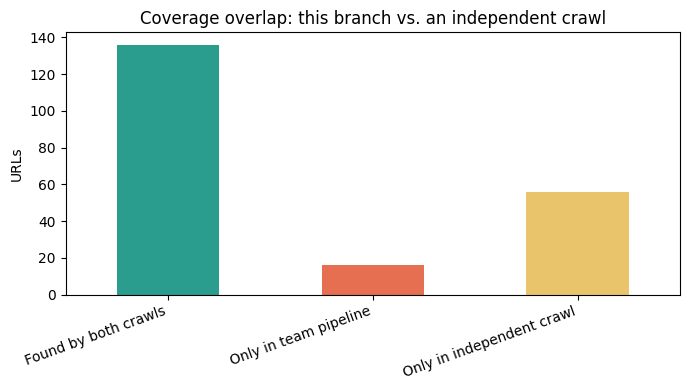

In [8]:
import subprocess

result = subprocess.run(['python3', 'scripts/validate_coverage.py'], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

coverage = pd.read_csv(PROCESSED / 'db-unza26-csc4792-team9-coverage-validation.csv', sep='|')

both = ((coverage['in_team_pipeline']) & (coverage['in_blessing_crawl'])).sum()
only_team = ((coverage['in_team_pipeline']) & (~coverage['in_blessing_crawl'])).sum()
only_other = ((~coverage['in_team_pipeline']) & (coverage['in_blessing_crawl'])).sum()

overlap = pd.Series(
    {'Found by both crawls': both, 'Only in team pipeline': only_team, 'Only in independent crawl': only_other}
)
fig, ax = plt.subplots(figsize=(7, 4))
overlap.plot.bar(ax=ax, color=['#2a9d8f', '#e76f51', '#e9c46a'])
ax.set_ylabel('URLs')
ax.set_title('Coverage overlap: this branch vs. an independent crawl')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

**Reading the difference — inspected by hand, not just counted:**

- **136 URLs were found by both crawls independently.** That agreement, not
  either crawl's raw total, is the real evidence this dataset's coverage is
  sound.
- **Most of the "only in the independent crawl" URLs are not missed
  content** — they're WordPress navigation artifacts a generic
  breadth-first crawl picked up along the way: pagination
  (`?paged=N&author=12`, `?paged=N&cat=1`), author/category archive listings
  (`?author=12`, `?cat=1`), and numeric `?p=NNNN` permalinks that are
  duplicate URL forms of pages already covered here under their
  `?page_id=` form.
- **One genuine crawler edge case surfaced this way**: that crawler applies
  its same-domain filter only to page links, not PDF links, so it followed
  an off-domain PDF from a *different* council's site
  (`lusangazicouncil.gov.zm`) — correctly flagged here as not a Luanshya
  source rather than silently included.
- **Most of the "only in team pipeline" URLs are individual news-post
  permalinks** from this branch's dedicated news-archive walk (outside the
  other crawl's depth/page cap), plus a few documents published *after*
  that crawl ran on 2026-09-11 (e.g. the 2026 CDF community-project lists,
  published 2026-09).

Full URL-by-URL detail: `data/processed/db-unza26-csc4792-team9-coverage-validation.csv`.